In [1]:
import scipy
from scipy.stats import skewnorm
import matplotlib.pyplot as plt
import numpy as np
import csv
import time
import pandas as pd
import varray as va
import ldax_processing as ldax
from datetime import datetime
from scipy.optimize import curve_fit, minimize

In [2]:
# load latest RQ file without amplification
data_lib = '/Users/bfeike/Documents/TPC_RQs'
raw_lib = '/Users/bfeike/Documents/TPC_data'
d51 = va.load(f'{data_lib}/2026-02-13-1413_RQ.vrz')
d52 = va.load(f'{data_lib}/2026-02-13-1426_RQ.vrz')
d53 = va.load(f'{data_lib}/2026-02-13-1434_RQ.vrz')
d54 = va.load(f'{data_lib}/2026-02-13-1443_RQ.vrz')
d55 = va.load(f'{data_lib}/2026-02-13-1451_RQ.vrz')
d56 = va.load(f'{data_lib}/2026-02-13-1459_RQ.vrz')
d57 = va.load(f'{data_lib}/2026-02-11-1315_000000_RQ.vrz')
dlist = [d51, d52, d53, d54, d55, d56, d57]

In [3]:
ch_arr = np.arange(32)
def spe_cut(d, j):
    #cut_oce = d['p_class'] == 3
    ch_arr = np.arange(32)
    all_ch_area = []
    all_ch_height = []
    all_ch_eventids = []
    all_ch_pulseids = []
    spe_area = []
    spe_height = []
    spe_mean_area = []
    spe_mean_height = []
    
    # Calculate all channel pulse areas and heights with cut applied:
    
    for ch in ch_arr:
        ch_area = d['p_area_ch'][:,ch,:].flatten()
        ch_eventid_arr = d['p_area_ch'].get_row_index()[:,ch,:].flatten()
        ch_pulseid_arr = d['p_area_ch'].get_col_index()[:,ch,:].flatten()
        ch_height = d['p_height_ch'][:,ch,:].flatten()
        if j == 51:
            cut_spe = (ch_height < 17.5) & (ch_height > 5) & (ch_area > 0)
        elif j == 52:
            cut_spe = (ch_height < 21) & (ch_height > 6) & (ch_area > 0)
        elif j == 53:
            cut_spe = (ch_height < 24) & (ch_height > 7) & (ch_area > 0)
        elif j == 54:
            cut_spe = (ch_height < 28) & (ch_height > 8) & (ch_area > 0)
        elif j == 55:
            cut_spe = (ch_height < 31) & (ch_height > 10) & (ch_area > 0)
        elif j == 56:
            cut_spe = (ch_height < 35) & (ch_height > 10) & (ch_area > 0)            
        elif j == 57:
            cut_spe = (ch_height < 38) & (ch_height > 10) & (ch_area > 0)
        
        ch_spe_area = ch_area[cut_spe]
        ch_spe_height = ch_height[cut_spe]
        ch_spe_mean_area = np.mean(ch_spe_area)
        ch_spe_mean_height = np.mean(ch_spe_height)
    
        all_ch_area.append(ch_area)
        all_ch_height.append(ch_height)
        all_ch_eventids.append(ch_eventid_arr)
        all_ch_pulseids.append(ch_pulseid_arr)
        spe_area.append(ch_spe_area)
        spe_height.append(ch_spe_height)
        spe_mean_area.append(ch_spe_mean_area)
        spe_mean_height.append(ch_spe_mean_height)
        
    return all_ch_area, all_ch_height, all_ch_eventids, all_ch_pulseids, spe_area, spe_height, spe_mean_area, spe_mean_height

In [4]:
# Error of the mean estimation (Poisson statistics)
def mu_err(spe_area, spe_height, ch_arr):
    sigma_area_arr = []
    sigma_height_arr = []
    stmean_area_arr = []
    stmean_height_arr = []

    for ch in ch_arr:
        n = len(spe_area[ch])
        sigma_area_arr.append(np.std(spe_area[ch]))
        sigma_height_arr.append(np.std(spe_height[ch]))
        stmean_area_arr.append(np.std(spe_area[ch])/np.sqrt(n))
        stmean_height_arr.append(np.std(spe_height[ch])/np.sqrt(n))
        
    return sigma_area_arr, sigma_height_arr, stmean_area_arr, stmean_height_arr

In [5]:
ddict = {}
err_dict = {}
for i in np.arange(7):
    all_ch_area, all_ch_height, all_ch_eventids, all_ch_pulseids, spe_area, spe_height, spe_mean_area, spe_mean_height = spe_cut(dlist[i],i+51)
    ddict[f'{i+51}'] = [all_ch_area, all_ch_height, all_ch_eventids, all_ch_pulseids, spe_area, spe_height, spe_mean_area, spe_mean_height]
    sigma_area_arr, sigma_height_arr, stmean_area_arr, stmean_height_arr = mu_err(spe_area, spe_height, ch_arr)
    err_dict[f'{i+51}'] = [sigma_area_arr, sigma_height_arr, stmean_area_arr, stmean_height_arr]

In [6]:
# Fit functions
def negativeLogLikelihoodSkewGaussian(params, counts, bins):
    mu = params[0]
    sigma = params[1]
    totalCount = params[2]
    skew = params[3]
    binCdfs = skewnorm.cdf(bins, skew, loc=mu, scale=sigma)
    lambdas = totalCount*np.diff(binCdfs)
    
    return np.sum(-counts*np.log(lambdas)+lambdas)

def Gaussian(x, peak, sigma, mu):
    return(peak*(1/(sigma*np.sqrt(2*np.pi)))*np.exp((-(x-mu)**2/(2*sigma**2))))

def area_func(v, a, vbrk):
    return a*(v-vbrk)

def skewfit(volts, ch_arr):
    pres = np.zeros((32, 4))
    for ch in ch_arr:
        fig, axs = plt.subplots(nrows=16, ncols=2);
        ax = axs.flatten();
        counts, bins, patches = ax[ch].hist(ddict[f'{volts}'][4][ch], edgecolor='black', bins=75, range=[0,50e1]);
        plt.close()
        params = [ddict[f'{volts}'][6][ch], err_dict[f'{volts}'][0][ch], len(ddict[f'{volts}'][4][ch]), 1]
        res = minimize(negativeLogLikelihoodSkewGaussian,x0=params,args=(counts,bins),bounds=[(0,1000),(None,None),(None, None),(-100,100)])
        pres[ch] = res.x
        
    return pres

def gaussfit(volts, ch_arr):
    pres = np.zeros((32, 3))
    prescov = np.zeros((32,3,3))
    err_mean_area = np.zeros((32))
    for ch in ch_arr:
        fig, axs = plt.subplots(nrows=16, ncols=2);
        ax = axs.flatten();
        counts, bins, patches = ax[ch].hist(ddict[f'{volts}'][4][ch], edgecolor='black', bins=75, range=[0,50e1]);
        plt.close()
        bins = (bins[:-1]+bins[1:])/2
        popt, pcov = curve_fit(Gaussian,xdata=bins,ydata=counts,p0=(100,20,100),sigma=err_dict[f'{volts}'][0][ch],bounds=([0,0,0],[100000,100,1000]),maxfev=10000)
        pres[ch] = popt
        prescov[ch] = pcov
        err_mean_area[ch] = pcov[2,2]
        
    return pres, prescov, err_mean_area
    
def linfit(v_bias, mu_area, sigmar, ch_arr):
    pbias = np.zeros((32, 2))
    pcov = np.zeros((32,2,2))
    for ch in ch_arr:
        v_b, v_b_cov = curve_fit(area_func,xdata=v_bias,ydata=mu_area[:,ch,2],p0=(25,25),sigma=np.sqrt(sigmar[:,ch]),bounds=([-100,-100],[100,100]),maxfev=10000)
        pbias[ch] = v_b
        pcov[ch] = v_b_cov
        
    return pbias, pcov

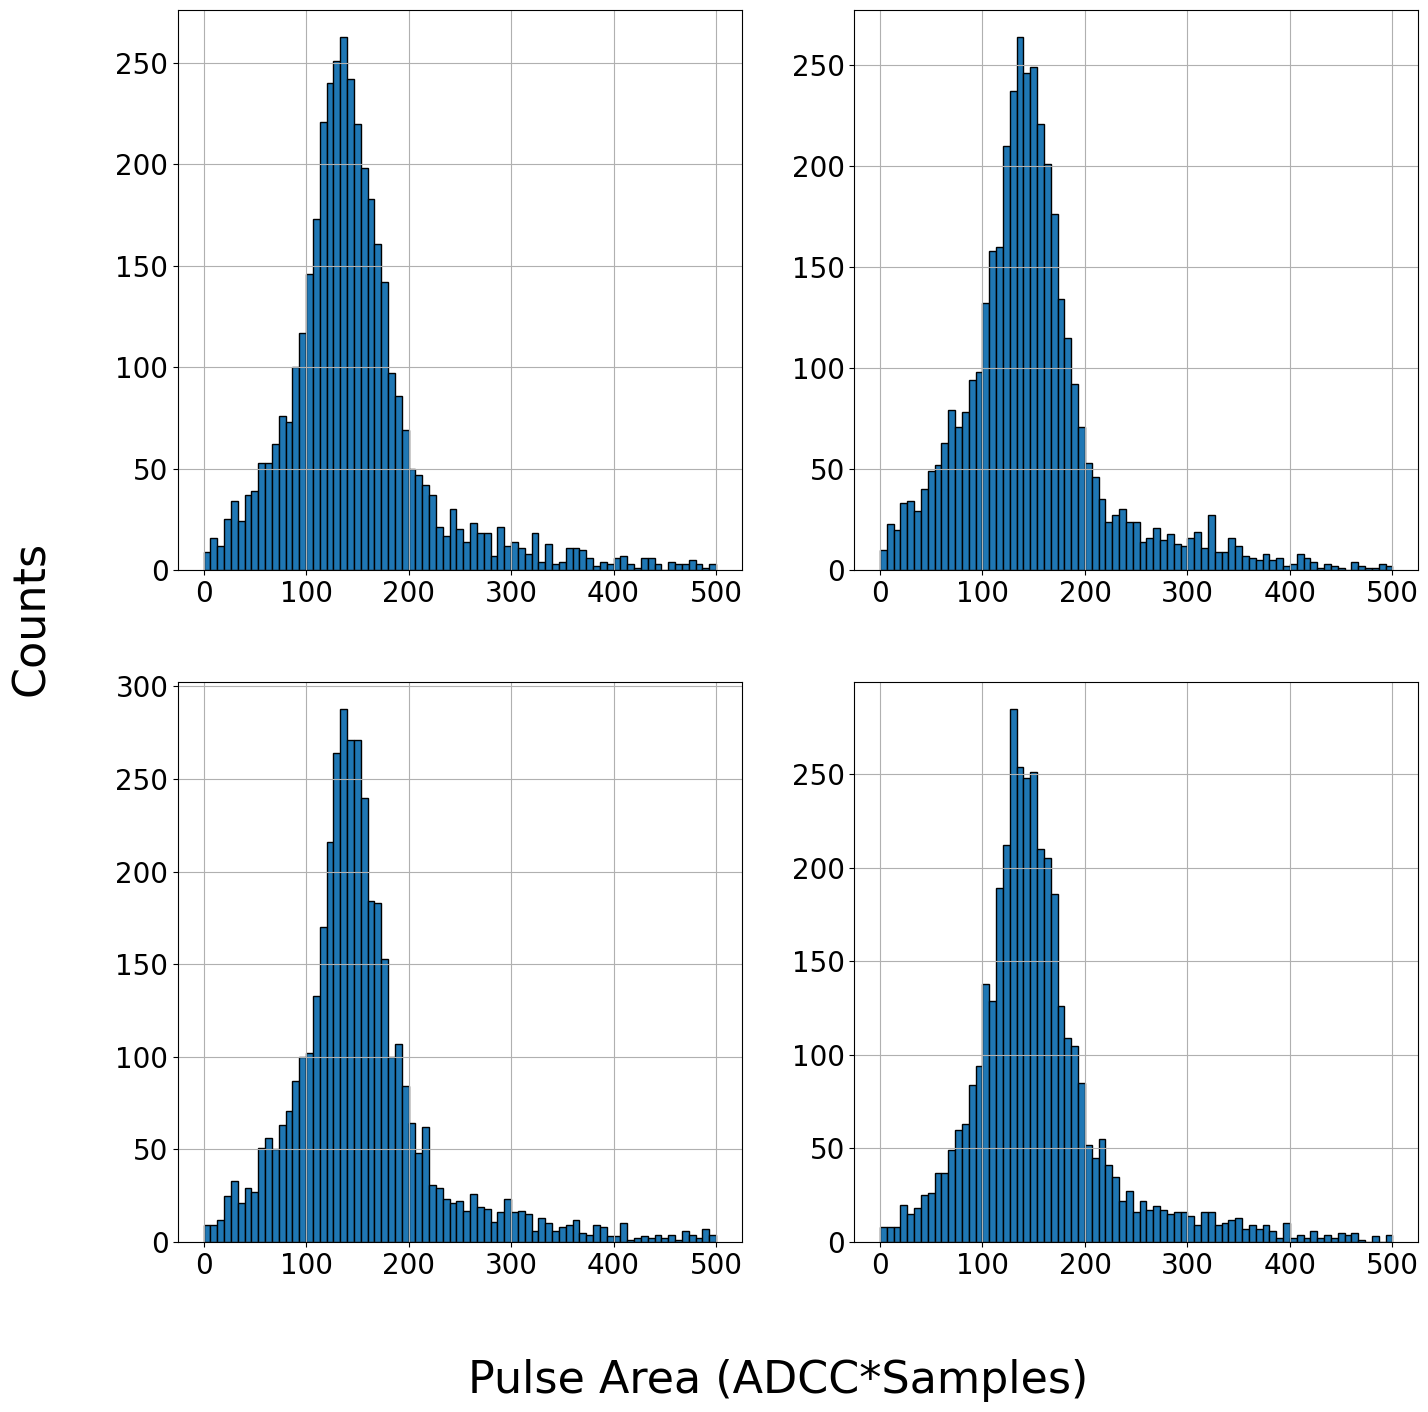

In [7]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
for i in np.arange(len(axs)+2):
    ax = axs.flatten()
    ax[i].hist(ddict['51'][4][i+24], edgecolor='black', bins=75, range=[0,50e1])
    #ax[i].set_yscale('log')
    ax[i].grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=32)
fig.supylabel('Counts', fontsize=32)
#plt.savefig('PulseArea_24-27.png')
plt.show()

In [8]:
pres = np.zeros((7,32,3))
prescov = np.zeros((7,32,3,3))
err_mean_area = np.zeros((7,32))
v_bias = [51, 52, 53, 54, 55, 56, 57]

for i in np.arange(len(v_bias)):
    res, cov, err = gaussfit(v_bias[i], ch_arr)
    pres[i] = res
    prescov[i] = cov
    err_mean_area[i] = err

pbias, pcov = linfit(v_bias, pres, err_mean_area, ch_arr)

In [9]:
mu_area = np.zeros((32, 7))
err_mu_area = np.zeros((32, 7))
for i in ch_arr:
    for j in v_bias:
        k = j-51
        mu_area[i, k] = ddict[f'{j}'][6][i]
        err_mu_area[i, k] = err_dict[f'{j}'][2][i]

In [10]:
print("Breakdown Voltages")
for ch in ch_arr:
    print(f'Channel {ch}: {pbias[ch,1]:.5g} +/- {np.sqrt(pcov[ch,1,1]):.3g}')

Breakdown Voltages
Channel 0: 45.896 +/- 0.0876
Channel 1: 46.002 +/- 0.139
Channel 2: 45.794 +/- 0.0435
Channel 3: 45.996 +/- 0.0991
Channel 4: 45.714 +/- 0.0787
Channel 5: 45.809 +/- 0.171
Channel 6: 46.025 +/- 0.117
Channel 7: 46.012 +/- 0.121
Channel 8: 45.754 +/- 0.146
Channel 9: 46.108 +/- 0.15
Channel 10: 46.018 +/- 0.131
Channel 11: 45.875 +/- 0.153
Channel 12: 45.834 +/- 0.0781
Channel 13: 45.866 +/- 0.124
Channel 14: 45.828 +/- 0.123
Channel 15: 45.884 +/- 0.11
Channel 16: 46.376 +/- 0.177
Channel 17: 46.327 +/- 0.0588
Channel 18: 46.495 +/- 0.0884
Channel 19: 46.314 +/- 0.0939
Channel 20: 46.267 +/- 0.0617
Channel 21: 46.334 +/- 0.114
Channel 22: 46.269 +/- 0.0623
Channel 23: 46.288 +/- 0.0923
Channel 24: 46.286 +/- 0.109
Channel 25: 46.118 +/- 0.123
Channel 26: 46.019 +/- 0.0721
Channel 27: 46.156 +/- 0.124
Channel 28: 45.96 +/- 0.0889
Channel 29: 46.114 +/- 0.0902
Channel 30: 46.308 +/- 0.118
Channel 31: 46.456 +/- 0.133


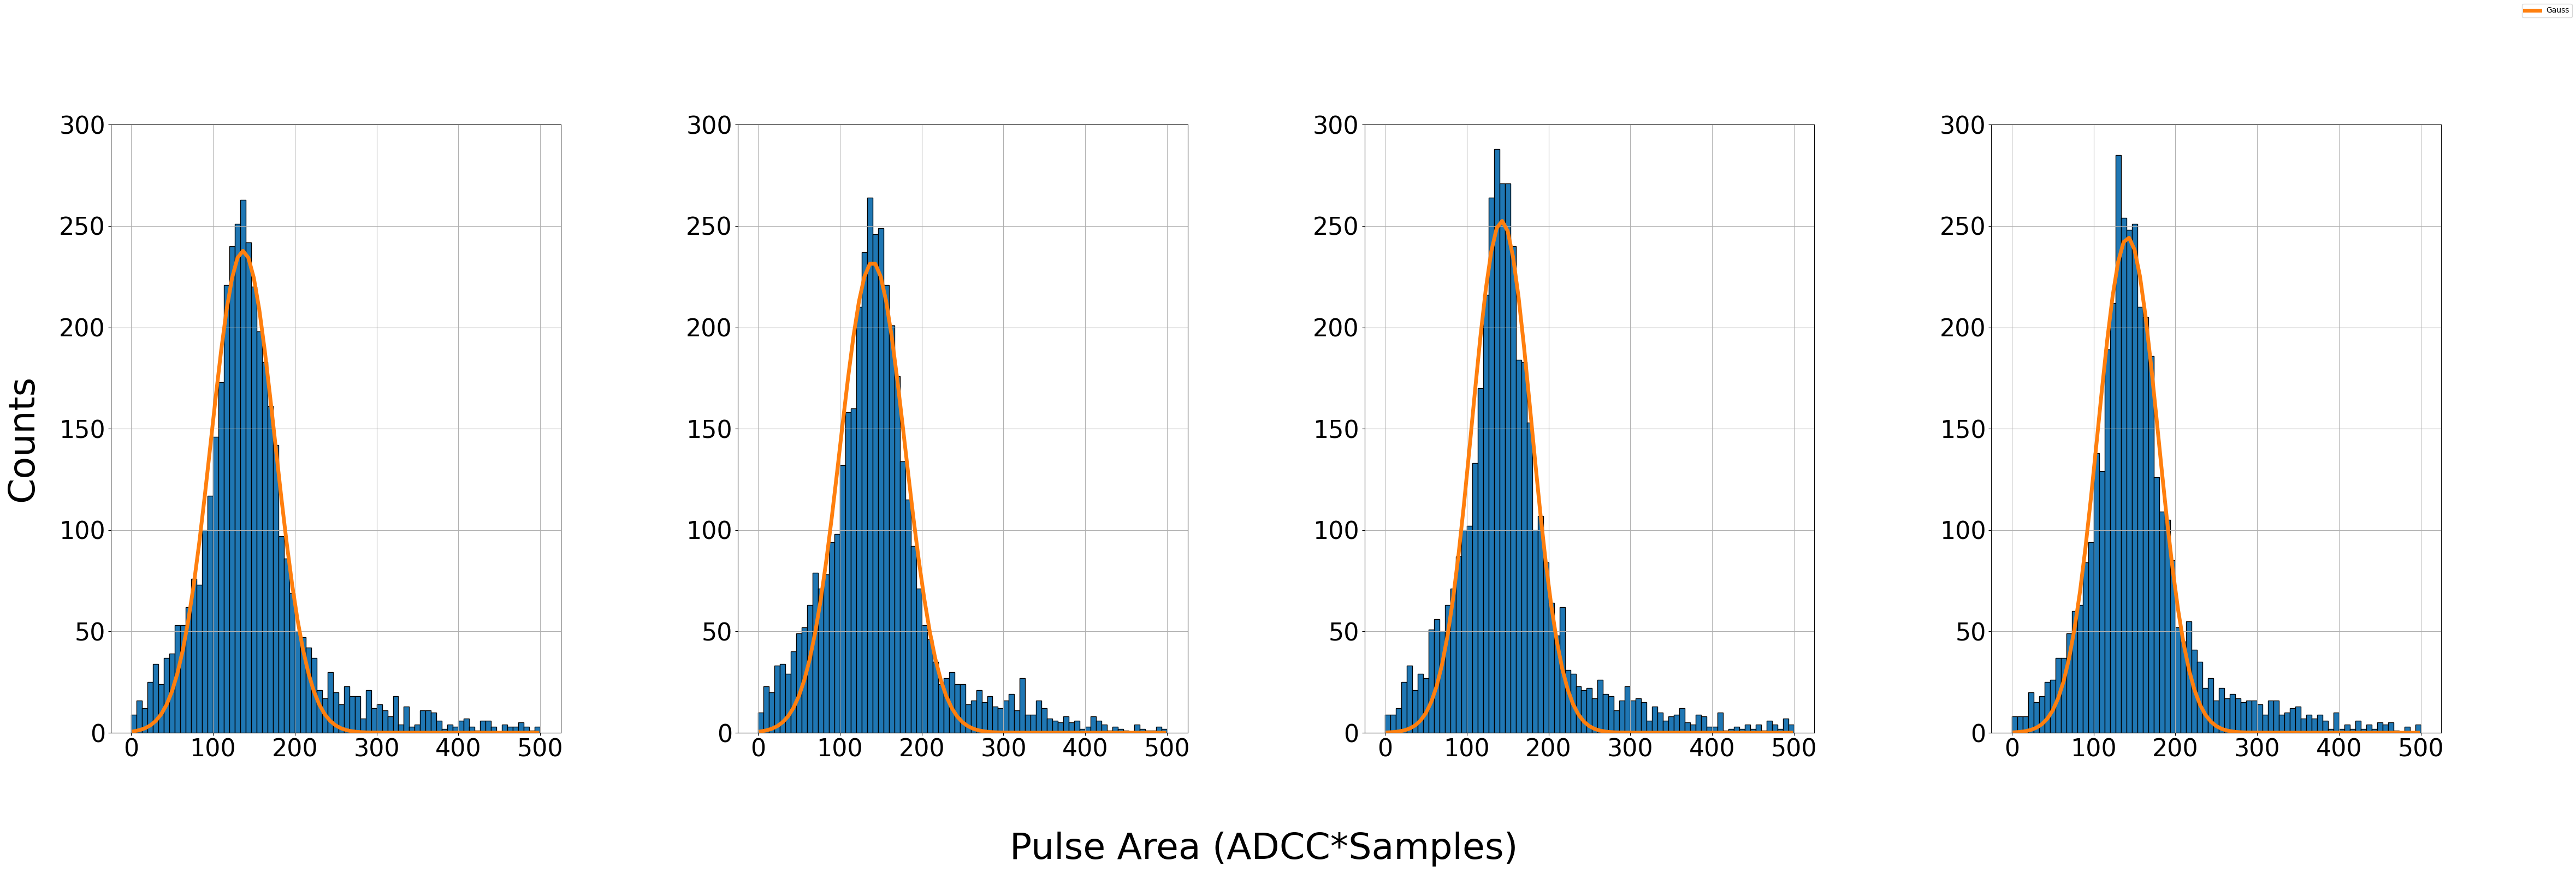

In [11]:
plt.rc('xtick', labelsize=32)
plt.rc('ytick', labelsize=32)
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(48,16))
plt.tight_layout(pad=15, h_pad=None, w_pad=None, rect=None)
for i in np.arange(4):
    j = i+24
    ax = axs.flatten()
    counts, bins, patches = ax[i].hist(ddict['51'][4][j], edgecolor='black', bins=75, range=[0,50e1])
    bins = (bins[:-1]+bins[1:])/2
    ax[i].plot(bins, Gaussian(bins, pres[0,j,0], pres[0,j,1], pres[0,j,2]), lw=5)
    ax[i].set_ylim(0,300)
    ax[i].grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=48)
fig.supylabel('Counts', fontsize=48)
fig.legend(labels=['Gauss'])
#plt.savefig('PulseAreaGaussian_24-27.png')
plt.show()

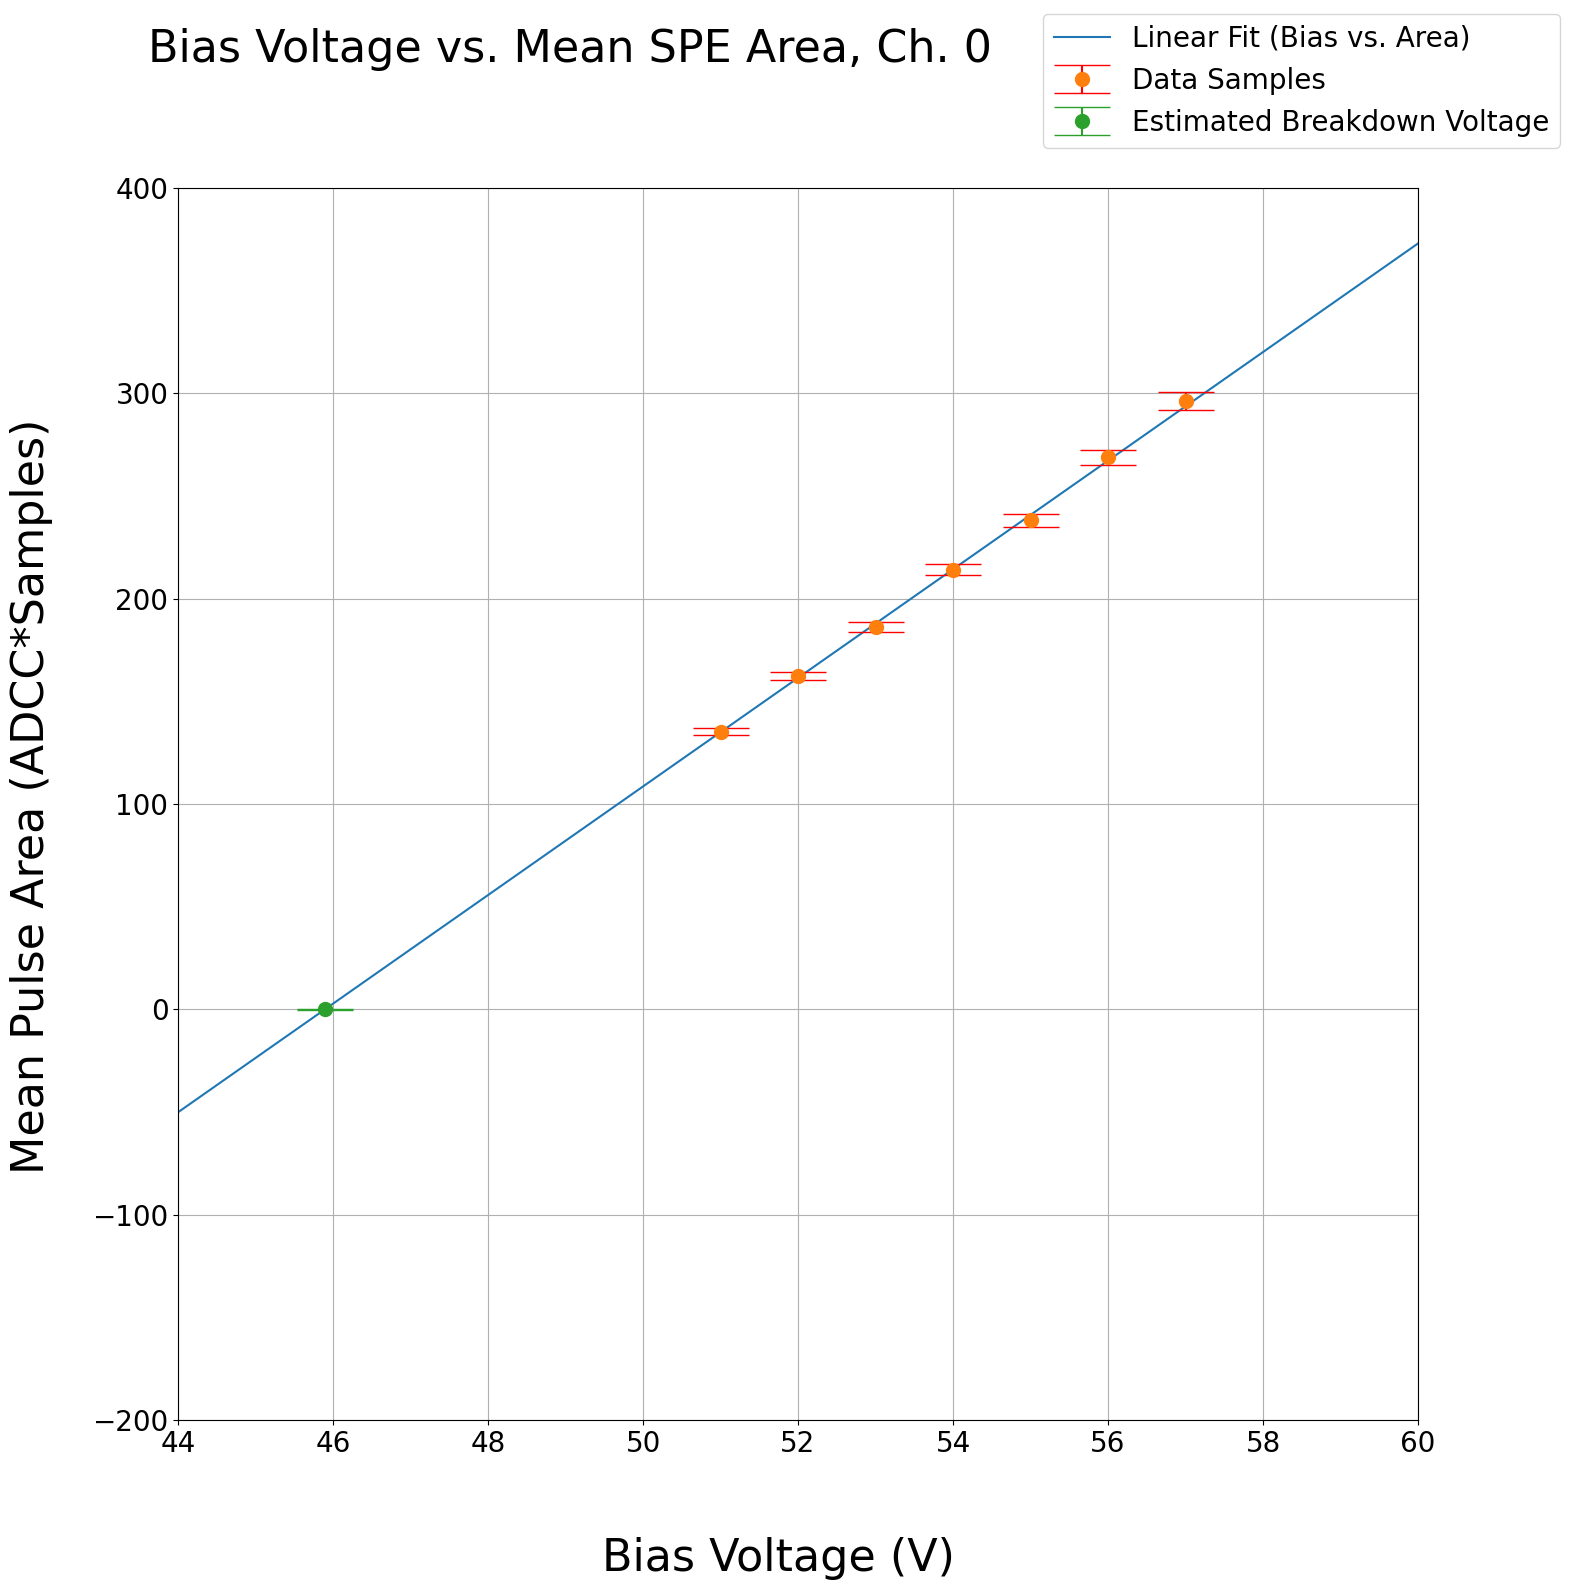

In [25]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
v_b = np.arange(30, 70, 1)

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(16,16))
j = i+0
axs.plot(v_b, area_func(v_b, pbias[0][0], pbias[0][1]))
axs.errorbar(v_bias, pres[:,0,2], yerr=np.sqrt(err_mean_area.T[0]), fmt='.', ecolor='r', ms=20, capsize=20)
axs.errorbar(pbias[0,1], 0, yerr=np.sqrt(pcov[ch,1,1]), fmt='.', ms=20, capsize=20)
axs.set_xlim(44, 60)
axs.set_ylim(-200, 400)
axs.grid()
fig.supxlabel('Bias Voltage (V)', fontsize=32)
fig.supylabel('Mean Pulse Area (ADCC*Samples)', fontsize=32)
fig.suptitle('Bias Voltage vs. Mean SPE Area, Ch. 0', fontsize=32, x=0.37)
fig.legend(labels=['Linear Fit (Bias vs. Area)', 'Data Samples','Estimated Breakdown Voltage'], fontsize=20)
plt.show()